# Predicting London House Prices with Multiple Linear Regression

This project explores how multiple linear regression can be used to predict London house prices using property size, location, tenure, property type, and energy rating.

In [103]:
import zipfile
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import ipywidgets as widgets
from IPython.display import display

In [54]:
def wrangle(zip_path):
    # Load the raw CSV file from the Kaggle ZIP archive.
    csv_file = "kaggle_london_house_price_data.csv"

    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(csv_file) as f:
            df = pd.read_csv(f)

    # Filter to only contain houses with a high sales price confidence estimate 
    df = df[df["saleEstimate_confidenceLevel"] == "HIGH"].copy()
    # Drop extremely rare tenure categories. 
    df = df[df["tenure"].isin(["Leasehold", "Freehold"])].copy()
    #Drop rows with missing values 
    df = df.dropna(subset=["floorAreaSqM", "propertyType", "currentEnergyRating"])

    # Engineer an approximate distance from central London using latitude and longitude. 
    central_london_lat = 51.5074
    central_london_lon = -0.1278

    df["distance_from_centre"] = np.sqrt(
        (df["latitude"] - central_london_lat) ** 2
        + (df["longitude"] - central_london_lon) ** 2
    )

    # Log-transform skewed price and area variables for linear regression.
    df["log_price"] = np.log1p(df["saleEstimate_currentPrice"])
    df["log_area"] = np.log1p(df["floorAreaSqM"])

    # Group rare outcodes to reduce sparse one-hot encoded features.
    outcode_counts = df["outcode"].value_counts()
    rare_outcodes = outcode_counts[outcode_counts < 30].index
    df["outcode_grouped"] = df["outcode"].replace(rare_outcodes, "Other")

    # Group rare property types while preserving the main property categories.
    property_counts = df["propertyType"].value_counts()
    rare_property_types = property_counts[property_counts < 1000].index
    df["propertyType_grouped"] = df["propertyType"].replace(
        rare_property_types,
        "Other"
    )

    # Drop leaky, high-cardinality, redundant, and no-longer-needed columns.
    df = df.drop(columns=[
        "history_numericChange",
        "history_percentageChange",
        "history_price",
        "history_date",
        "saleEstimate_valueChange.saleDate",
        "saleEstimate_valueChange.percentageChange",
        "saleEstimate_valueChange.numericChange",
        "saleEstimate_ingestedAt",
        "saleEstimate_upperPrice",
        "saleEstimate_lowerPrice",
        "rentEstimate_upperPrice",
        "rentEstimate_currentPrice",
        "rentEstimate_lowerPrice",
        "fullAddress",
        "postcode",
        "country",
        "latitude",
        "longitude",
        "saleEstimate_confidenceLevel"
    ])

    return df

In [55]:
df = wrangle("archive.zip")
df.head()

,outcode,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,saleEstimate_currentPrice,distance_from_centre,log_price,log_area,outcode_grouped,propertyType_grouped
3,SE5,1.0,1.0,64.0,1.0,Leasehold,Flat/Maisonette,D,388000.0,0.046052,12.868763,4.174387,SE5,Flat/Maisonette
4,N10,1.0,4.0,137.0,2.0,Freehold,End Terrace House,D,1261000.0,0.082225,14.047416,4.927254,N10,End Terrace House
5,SE3,1.0,2.0,97.0,1.0,Freehold,Mid Terrace House,D,944000.0,0.140957,13.757883,4.584967,SE3,Mid Terrace House
6,SE13,1.0,3.0,135.0,2.0,Freehold,Terrace Property,E,726000.0,0.132663,13.495307,4.912655,SE13,Terrace Property
7,SW1W,1.0,5.0,346.0,NaN,Freehold,Mid Terrace House,D,6024000.0,0.019954,15.611262,5.849325,SW1W,Mid Terrace House


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244265 entries, 3 to 418200
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   outcode                    244265 non-null  object 
 1   bathrooms                  217294 non-null  float64
 2   bedrooms                   233645 non-null  float64
 3   floorAreaSqM               244265 non-null  float64
 4   livingRooms                226224 non-null  float64
 5   tenure                     244265 non-null  object 
 6   propertyType               244265 non-null  object 
 7   currentEnergyRating        244265 non-null  object 
 8   saleEstimate_currentPrice  244265 non-null  float64
 9   distance_from_centre       244265 non-null  float64
 10  log_price                  244265 non-null  float64
 11  log_area                   244265 non-null  float64
 12  outcode_grouped            244265 non-null  object 
 13  propertyType_grouped       244265 

In [57]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

bathrooms                    11.041697
livingRooms                   7.385831
bedrooms                      4.347737
outcode                       0.000000
floorAreaSqM                  0.000000
tenure                        0.000000
propertyType                  0.000000
currentEnergyRating           0.000000
saleEstimate_currentPrice     0.000000
distance_from_centre          0.000000
log_price                     0.000000
log_area                      0.000000
outcode_grouped               0.000000
propertyType_grouped          0.000000
dtype: float64

In [58]:
df.describe()

,bathrooms,bedrooms,floorAreaSqM,livingRooms,saleEstimate_currentPrice,distance_from_centre,log_price,log_area
count,217294.000000,233645.000000,244265.000000,226224.000000,2.442650e+05,244265.000000,244265.000000,244265.000000
mean,1.419772,2.574602,99.748535,1.303549,8.094597e+05,0.104482,13.410028,4.511212
std,0.662193,1.122752,50.220609,0.562724,6.560477e+05,0.049939,0.574908,0.438449
min,1.000000,1.000000,13.000000,1.000000,8.900000e+04,0.001267,11.396403,2.639057
25%,1.000000,2.000000,66.000000,1.000000,4.460000e+05,0.067384,13.008076,4.204693
50%,1.000000,2.000000,87.000000,1.000000,6.070000e+05,0.099074,13.316286,4.477337
75%,2.000000,3.000000,118.000000,2.000000,9.120000e+05,0.136076,13.723396,4.779123
max,7.000000,9.000000,500.000000,7.000000,1.245600e+07,0.268114,16.337713,6.216606


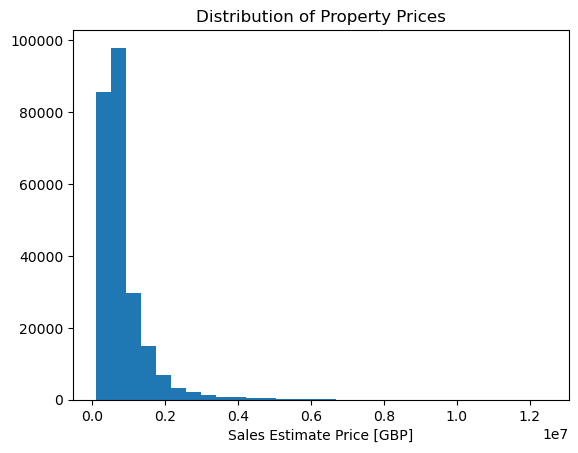

In [59]:
plt.hist(df["saleEstimate_currentPrice"], bins=30)
plt.xlabel("Sales Estimate Price [GBP]")
plt.title("Distribution of Property Prices");

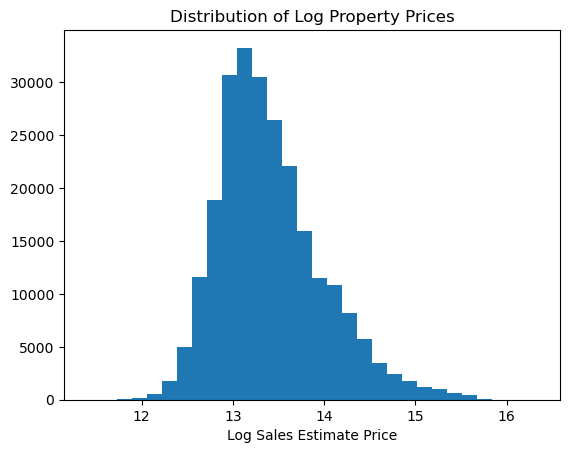

In [60]:
plt.hist(df["log_price"], bins=30)
plt.xlabel("Log Sales Estimate Price")
plt.title("Distribution of Log Property Prices");

The raw property price distribution is strongly right-skewed, with most properties concentrated at lower price values and a small number of very expensive properties creating a long tail. This can make a linear regression model overly influenced by high-value outliers.

After applying a log transformation, the price distribution becomes much more balanced and closer to a normal shape. For this reason, `log_price` will be used as the target variable in the regression model instead of the raw sale estimate price.

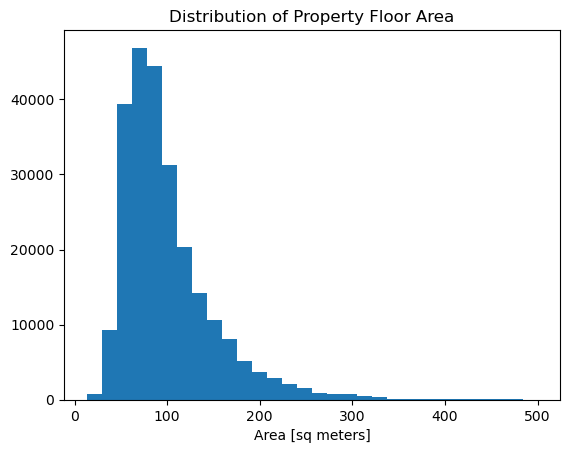

In [61]:
plt.hist(df["floorAreaSqM"], bins=30)
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Property Floor Area");

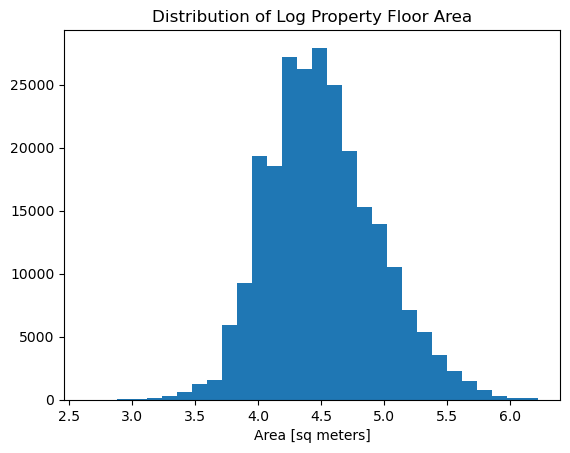

In [62]:
plt.hist(df["log_area"], bins=30)
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Log Property Floor Area");

The raw floor area distribution is right-skewed, with most properties concentrated below around 150 square metres and a small number of much larger properties forming a long tail.

After applying a log transformation, the distribution of floor area becomes more balanced and closer to a normal shape. Since this also helps create a more linear relationship with log price, `log_area` will be used as a predictor in the regression model instead of raw `floorAreaSqM`.

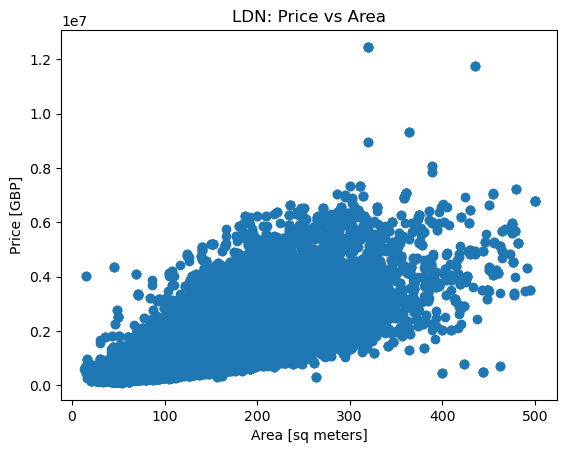

In [63]:
plt.scatter(x=df["floorAreaSqM"], y=df["saleEstimate_currentPrice"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [GBP]")
plt.title("LDN: Price vs Area");

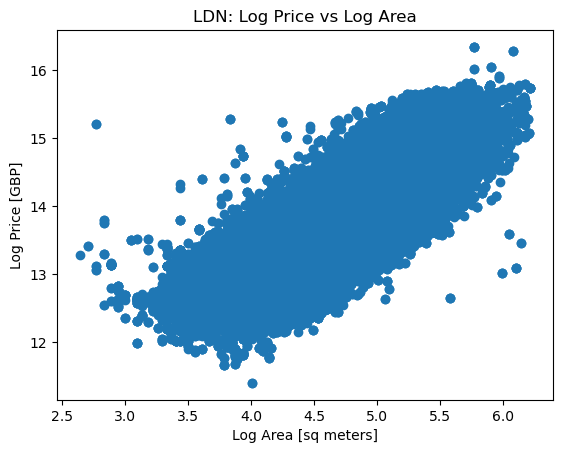

In [64]:
plt.scatter(x=df["log_area"], y=df["log_price"])
plt.xlabel("Log Area [sq meters]")
plt.ylabel("Log Price [GBP]")
plt.title("LDN: Log Price vs Log Area");

The raw price and floor area scatter plot shows a positive relationship: larger properties generally have higher estimated prices. However, the spread of prices increases as floor area increases, and several high-value outliers are visible.

After applying log transformations to both price and floor area, the relationship becomes more linear and the extreme values have less influence. This supports using `log_price` as the target variable and `log_area` as a predictor in the multiple linear regression model.

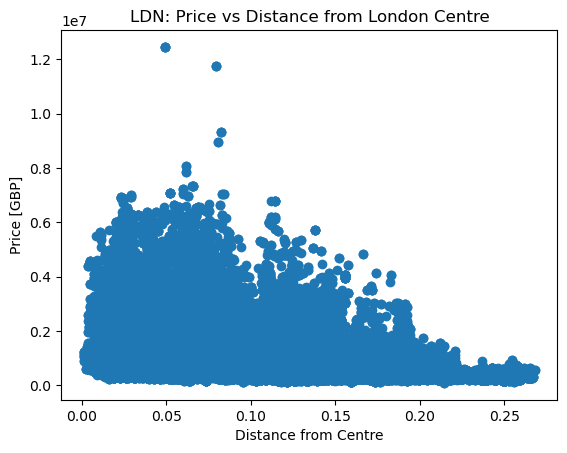

In [65]:
plt.scatter(x=df["distance_from_centre"], y=df["saleEstimate_currentPrice"])
plt.xlabel("Distance from Centre")
plt.ylabel("Price [GBP]")
plt.title("LDN: Price vs Distance from London Centre");

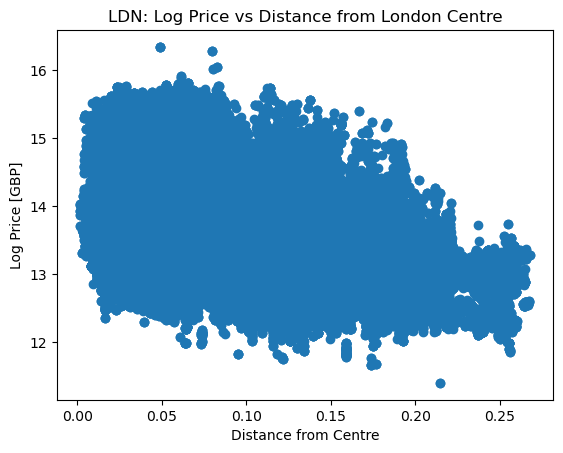

In [66]:
plt.scatter(x=df["distance_from_centre"], y=df["log_price"])
plt.xlabel("Distance from Centre")
plt.ylabel("Log Price [GBP]")
plt.title("LDN: Log Price vs Distance from London Centre");

The scatter plots show a negative relationship between distance from central London and property price. Properties closer to the centre generally have higher estimated prices, while properties farther away tend to have lower prices.

Using log price makes this relationship clearer and reduces the influence of very expensive outliers. `distance_from_centre` will therefore be included as a numeric predictor in the regression model, although it should be interpreted as an approximate distance measure based on latitude and longitude.

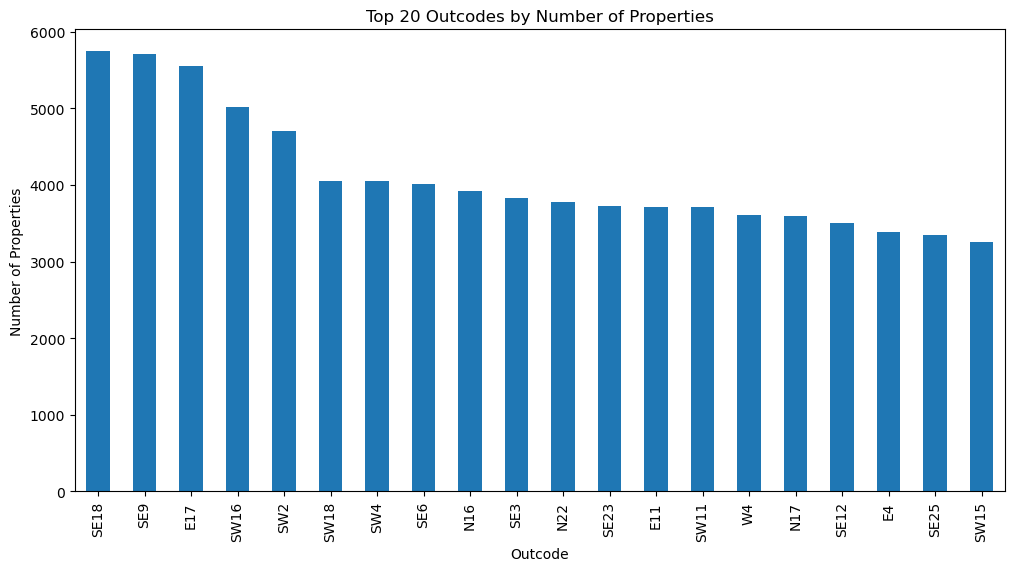

In [67]:
df["outcode"].value_counts().head(20).plot(
    kind="bar",
    figsize=(12, 6),
    title="Top 20 Outcodes by Number of Properties",
    ylabel="Number of Properties",
    xlabel="Outcode"
);

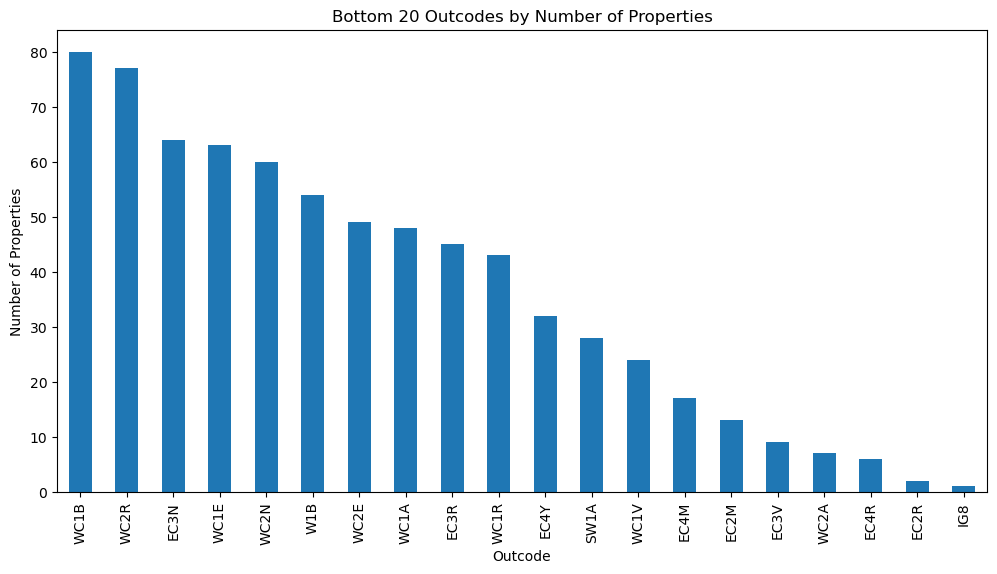

In [68]:
df["outcode"].value_counts().tail(20).plot(
    kind="bar",
    figsize=(12, 6),
    title="Bottom 20 Outcodes by Number of Properties",
    ylabel="Number of Properties",
    xlabel="Outcode"
);

The outcode count plots show that some locations are represented by thousands of properties, while others have very few observations. This imbalance is important because `outcode` will be treated as a categorical feature in the regression model.

Outcodes with very small sample sizes may produce unstable coefficients after one-hot encoding. To reduce this risk, rare outcodes are grouped into an `"Other"` category before modelling, while common outcodes are kept as separate location categories.

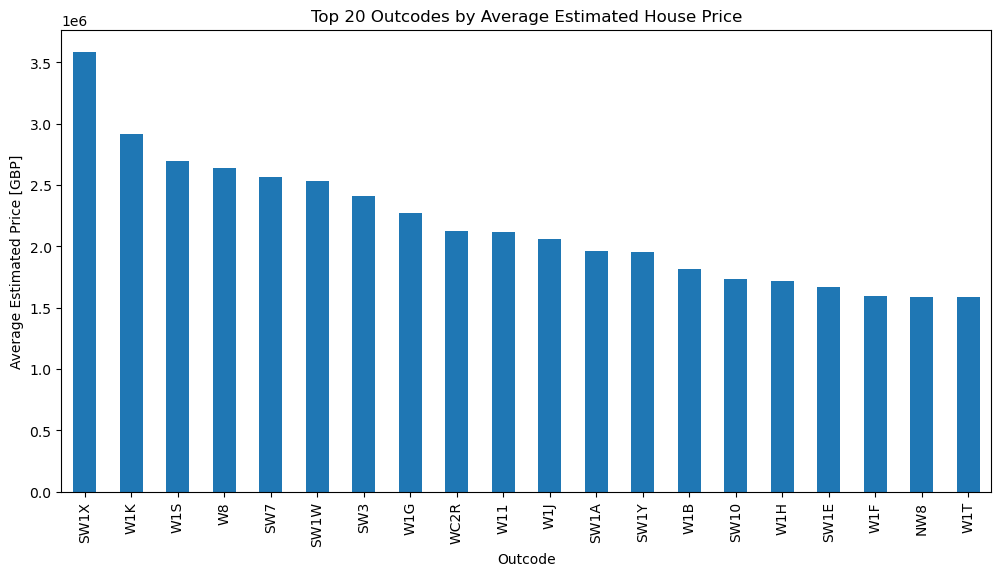

In [69]:
outcode_price = (
    df.groupby("outcode")["saleEstimate_currentPrice"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

outcode_price.plot(
    kind="bar",
    figsize=(12, 6),
    title="Top 20 Outcodes by Average Estimated House Price",
    ylabel="Average Estimated Price [GBP]",
    xlabel="Outcode"
);

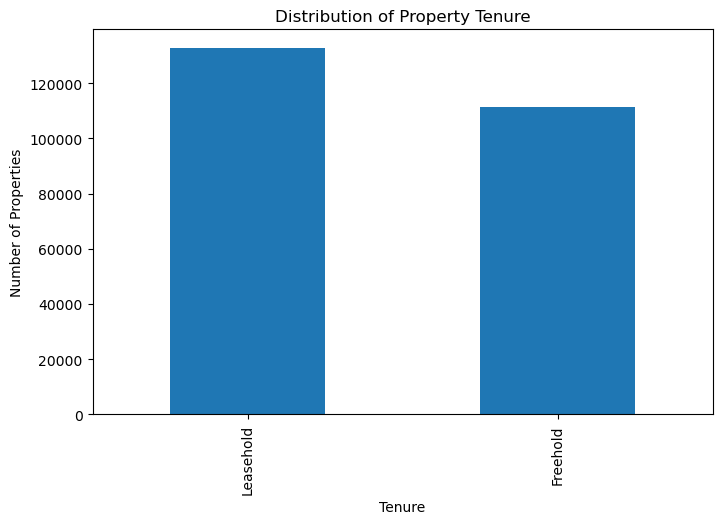

In [70]:
df["tenure"].value_counts().plot(
    kind="bar",
    figsize=(8, 5),
    title="Distribution of Property Tenure",
    ylabel="Number of Properties",
    xlabel="Tenure"
);

The tenure distribution shows that the dataset mainly contains Leasehold and Freehold properties, with Leasehold slightly more common. Rare tenure categories were removed earlier because they had very few observations and could lead to unstable regression coefficients.

Tenure will be included as a categorical predictor in the model, as ownership type may be associated with differences in property value.

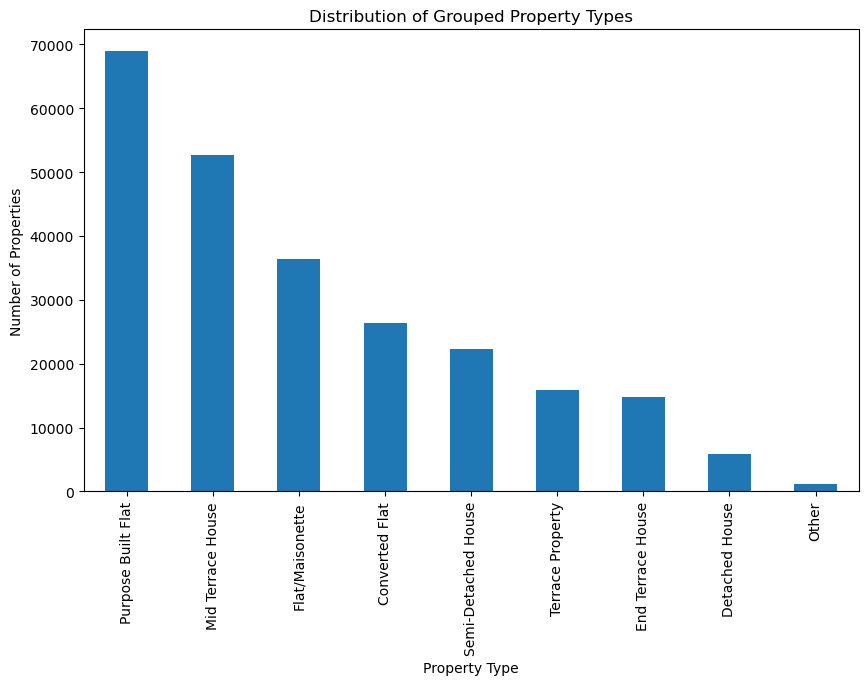

In [71]:
df["propertyType_grouped"].value_counts().plot(
    kind="bar",
    figsize=(10, 6),
    title="Distribution of Grouped Property Types",
    ylabel="Number of Properties",
    xlabel="Property Type"
);

The grouped property type distribution shows that most properties fall into a small number of common categories, especially Purpose Built Flat, Mid Terrace House, and Flat/Maisonette. Less common property types have been combined into an `"Other"` category.

This grouping helps reduce the number of sparse categories before one-hot encoding, making the regression model more stable while still preserving the main differences between property types.

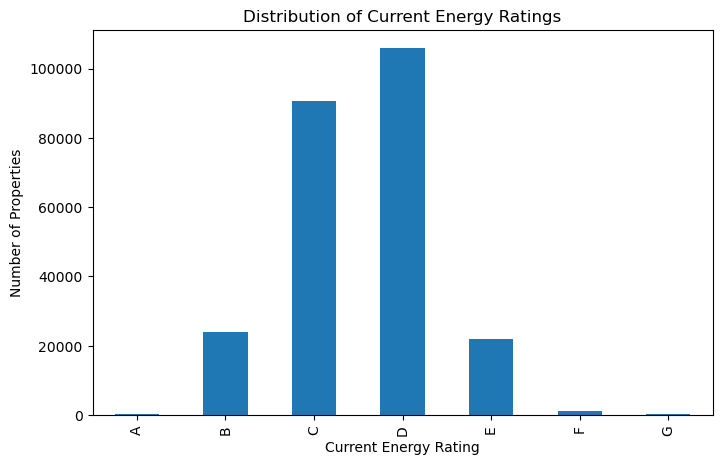

In [72]:
df["currentEnergyRating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5),
    title="Distribution of Current Energy Ratings",
    ylabel="Number of Properties",
    xlabel="Current Energy Rating"
);

The current energy rating distribution shows that most properties are rated C or D, with fewer properties rated B or E. Very few properties have the highest or lowest ratings, such as A, F, or G.

Energy rating will be kept as a categorical predictor in the model because it may reflect differences in property quality, efficiency, age, or condition. Although some categories have low counts, they are kept separate because the ratings have meaningful differences and grouping them could remove useful information.

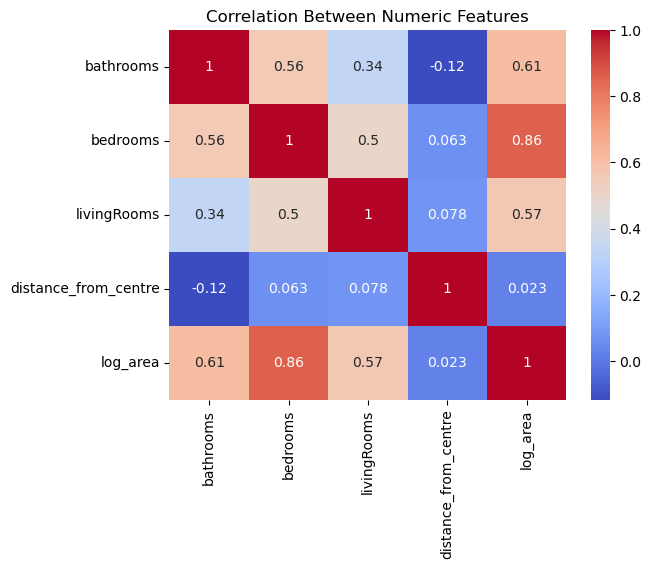

In [73]:
#corr = df.select_dtypes("number").corr()
corr = df[["bathrooms", "bedrooms", "livingRooms", "distance_from_centre", "log_area"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric Features");

The correlation heatmap shows that several size-related features are moderately to strongly correlated. In particular, `bedrooms` has a strong correlation with `log_area`, and `bathrooms` and `livingRooms` are also related to property size.

This suggests some multicollinearity may be present if all of these variables are included in the regression model. However, the features still capture slightly different aspects of a property, so they can be tested in the model and removed later if they reduce interpretability or do not improve performance.

`distance_from_centre` has low correlation with the other numeric features, meaning it provides separate location-based information.

## Modelling Decisions

The target variable, `saleEstimate_currentPrice`, is heavily right-skewed, so `log_price` will be used as the model target.

The floor area feature is also right-skewed, so `log_area` will be used instead of raw floor area.

Rare outcodes and rare property types were grouped to reduce unstable regression coefficients after one-hot encoding.

Energy rating categories were kept separate because they have meaningful order and may reflect important property quality differences.

The model will use a mix of numeric and categorical predictors. Categorical features will need one-hot encoding before fitting the multiple linear regression model.

## Split Data

In [74]:
target = "log_price"

numeric_features = [
    "log_area",
    "distance_from_centre",
    "bathrooms",
    "bedrooms",
    "livingRooms"
]

categorical_features = [
    "outcode_grouped",
    "tenure",
    "propertyType_grouped",
    "currentEnergyRating"
]

features = numeric_features + categorical_features

X = df[features]
y = df[target]

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195412, 9), (48853, 9), (195412,), (48853,))

The data is split into training and testing sets using an 80/20 split. The training set is used to fit the model, while the test set is kept separate to evaluate how well the model performs on unseen data.

A fixed `random_state` is used so that the split is reproducible each time the notebook is run.

# Build Model

## Baseline 

In [76]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

y_pred_baseline_log = baseline.predict(X_test)

baseline_r2 = r2_score(y_test, y_pred_baseline_log)
baseline_mae_log = mean_absolute_error(y_test, y_pred_baseline_log)
baseline_rmse_log = mean_squared_error(y_test, y_pred_baseline_log) ** 0.5

print("Baseline R²:", baseline_r2)
print("Baseline MAE log:", baseline_mae_log)
print("Baseline RMSE log:", baseline_rmse_log)

Baseline R²: -1.508439506636705e-08
Baseline MAE log: 0.45061823848417426
Baseline RMSE log: 0.5765263629117786


In [77]:
y_test_price = np.expm1(y_test)

y_pred_baseline_price = np.expm1(y_pred_baseline_log)

baseline_mae_price = mean_absolute_error(y_test_price, y_pred_baseline_price)
baseline_rmse_price = mean_squared_error(y_test_price, y_pred_baseline_price) ** 0.5

print("Baseline MAE price:", baseline_mae_price)
print("Baseline RMSE price:", baseline_rmse_price)

Baseline MAE price: 374789.1993115528
Baseline RMSE price: 671709.0394552206


A baseline model was created using the mean log price from the training set. This provides a simple benchmark to check whether the multiple linear regression model improves meaningfully over simply predicting the average property price.

## Iterate 

In [78]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

The preprocessing pipeline prepares the numeric and categorical features before fitting the regression model.

For numeric features, missing values are filled using the median. This is appropriate because housing data can contain outliers, and the median is less affected by extreme values than the mean. The numeric features are then scaled using `StandardScaler` so they are on a comparable scale.

For categorical features, missing values are filled using the most frequent category. The categorical variables are then converted into numeric dummy variables using one-hot encoding, with `handle_unknown="ignore"` to prevent errors if unseen categories appear in the test data.

The `ColumnTransformer` applies the numeric preprocessing steps to the numeric features and the categorical preprocessing steps to the categorical features in one combined preprocessing object.

In [79]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [80]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluate 

In [101]:
y_pred_log = model.predict(X_test)

r2 = r2_score(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = mean_squared_error(y_test, y_pred_log) ** 0.5

print("R²:", r2)
print("MAE log:", mae_log)
print("RMSE log:", rmse_log)

R²: 0.897457569401584
MAE log: 0.14141824474822726
RMSE log: 0.18461669483433416


The linear regression model explains approximately 89.7% of the variation in log property prices, based on the R² score. This is a large improvement over the baseline model, which had an R² close to 0 because it simply predicted the average log price for every property.

The regression model also reduced the log-scale errors substantially. The baseline MAE was around 0.451, while the regression model reduced this to around 0.141. The baseline RMSE was around 0.577, while the regression model reduced this to around 0.185. This shows that the selected property, location, and categorical features provide much more useful predictions than using the average price alone.

In [100]:
y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_log)

mae_price = mean_absolute_error(y_test_price, y_pred_price)
rmse_price = mean_squared_error(y_test_price, y_pred_price) ** 0.5

print("MAE price:", mae_price)
print("RMSE price:", rmse_price)

MAE price: 123147.20886538578
RMSE price: 235810.7292862621


After converting predictions back from log price to GBP, the regression model has a mean absolute error of approximately £123,147. This is a strong improvement over the baseline MAE of approximately £374,789, meaning the model reduces the average prediction error by about £252k.

The regression RMSE is approximately £235,810, compared with a baseline RMSE of approximately £671,709. This shows that the model also greatly reduces larger prediction errors. The RMSE is still higher than the MAE, which suggests that some expensive or unusual properties remain harder to predict, but the model performs much better than the baseline overall.

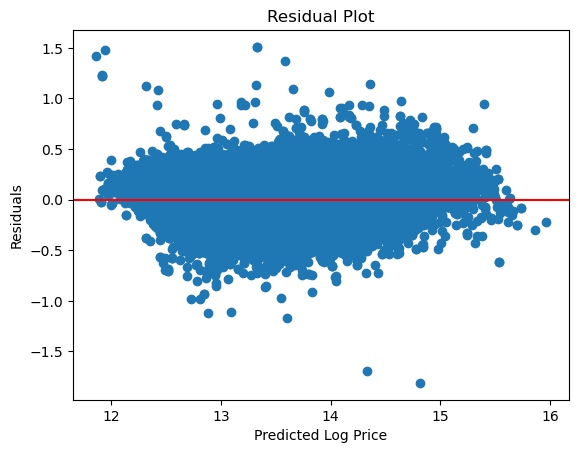

In [83]:
residuals = y_test - y_pred_log

plt.scatter(y_pred_log, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title("Residual Plot");

The residual plot shows that most residuals are centred around zero, which suggests that the model is not consistently overpredicting or underpredicting across the full range of predicted log prices.

However, the spread of residuals is not perfectly constant. There are some larger errors, especially around the middle and higher predicted price ranges, and a few clear outliers. This suggests that while the linear regression model performs well overall, it does not capture all of the complexity in London house prices.

## Coefficient Evaluation 

In [87]:
encoder = (
    model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
)

for feature, categories in zip(categorical_features, encoder.categories_):
    print(feature, "reference category:", categories[0])

outcode_grouped reference category: E1
tenure reference category: Freehold
propertyType_grouped reference category: Converted Flat
currentEnergyRating reference category: A


Because `drop="first"` was used in the one-hot encoder, each categorical coefficient is interpreted relative to a reference category.

The reference categories are:

- `outcode_grouped`: E1
- `tenure`: Freehold
- `propertyType_grouped`: Converted Flat
- `currentEnergyRating`: A

For example, a positive coefficient for `outcode_grouped_W1S` means that properties in W1S are predicted to be more expensive than otherwise similar properties in E1, holding all other features constant.

Similarly, the coefficient for `tenure_Leasehold` shows the expected difference between Leasehold and Freehold properties, holding other variables constant.

Because the model predicts `log_price`, these coefficients can be converted into approximate percentage differences using:

`(exp(coefficient) - 1) * 100`

In [88]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df["percent_change"] = (
    np.exp(coef_df["coefficient"]) - 1
) * 100


coef_df.sort_values("abs_coefficient", ascending=False).head()

,feature,coefficient,abs_coefficient,percent_change
136,cat__outcode_grouped_W1S,1.061419,1.061419,189.046841
135,cat__outcode_grouped_W1K,1.000470,1.000470,171.955891
113,cat__outcode_grouped_SW1X,0.938212,0.938212,155.540913
134,cat__outcode_grouped_W1J,0.837319,0.837319,131.016557
121,cat__outcode_grouped_SW7,0.776862,0.776862,117.463823


The strongest absolute coefficients are associated with high-value London outcodes such as W1S, W1K, SW1X, W1J, and SW7. Since the reference outcode is E1, these positive coefficients suggest that properties in these premium outcodes are predicted to be substantially more expensive than comparable properties in E1, holding property size, distance from centre, tenure, property type, and energy rating constant.

In [89]:
coef_df.sort_values("coefficient", ascending=True).head()

,feature,coefficient,abs_coefficient,percent_change
45,cat__outcode_grouped_N18,-0.378734,0.378734,-31.527252
57,cat__outcode_grouped_N9,-0.296269,0.296269,-25.641289
87,cat__outcode_grouped_SE25,-0.271677,0.271677,-23.789994
44,cat__outcode_grouped_N17,-0.221004,0.221004,-19.828650
104,cat__outcode_grouped_SW16,-0.214389,0.214389,-19.296530


The strongest negative coefficients are all associated with outcodes. Since the reference outcode is E1, these results suggest that properties in N18, N9, SE25, N17, and SW16 are predicted to be cheaper than comparable properties in E1, holding all other features constant.

For example, properties in N18 are predicted to be approximately 31.5% cheaper than comparable properties in E1. Similarly, N9 is associated with a 25.6% lower predicted price, SE25 with a 23.8% lower predicted price, N17 with a 19.8% lower predicted price, and SW16 with a 19.3% lower predicted price.

This reinforces that location is one of the most important predictors in the model.

In [93]:
numeric_coef_df = coef_df[coef_df["feature"].str.startswith("num_")].copy()
numeric_coef_df["percent_change"] = (
    np.exp(numeric_coef_df["coefficient"]) - 1
) * 100
numeric_coef_df

,feature,coefficient,abs_coefficient,percent_change
0,num__log_area,0.325640,0.325640,38.491698
1,num__distance_from_centre,-0.197654,0.197654,-17.934595
2,num__bathrooms,0.032505,0.032505,3.303920
3,num__bedrooms,0.008233,0.008233,0.826716
4,num__livingRooms,0.020847,0.020847,2.106618


The numeric coefficients show that `log_area` has the strongest positive relationship with predicted property price. A one-standard-deviation increase in `log_area` is associated with an estimated **38.5% increase** in property price, holding all other features constant.

`distance_from_centre` has the strongest negative numeric effect. A one-standard-deviation increase in distance from central London is associated with an estimated **17.9% decrease** in property price, holding all other features constant.

The remaining numeric features have smaller positive effects. A one-standard-deviation increase in `bathrooms` is associated with an estimated **3.3% increase** in price, `livingRooms` with a **2.1% increase**, and `bedrooms` with a **0.8% increase**.

Overall, the numeric coefficients suggest that property size and location are much more influential than the number of rooms in this model.

In [95]:
ptype_coef_df = coef_df[coef_df["feature"].str.startswith("cat__prop")].copy()
ptype_coef_df["percent_change"] = (
    np.exp(ptype_coef_df["coefficient"]) - 1
) * 100
ptype_coef_df

,feature,coefficient,abs_coefficient,percent_change
161,cat__propertyType_grouped_Detached House,0.199227,0.199227,22.045907
162,cat__propertyType_grouped_End Terrace House,0.072101,0.072101,7.476363
163,cat__propertyType_grouped_Flat/Maisonette,-0.086447,0.086447,-8.281594
164,cat__propertyType_grouped_Mid Terrace House,0.100299,0.100299,10.550163
165,cat__propertyType_grouped_Other,0.097328,0.097328,10.222224
166,cat__propertyType_grouped_Purpose Built Flat,-0.120941,0.120941,-11.391383
167,cat__propertyType_grouped_Semi-Detached House,0.129047,0.129047,13.774307
168,cat__propertyType_grouped_Terrace Property,0.074063,0.074063,7.687438


The property type coefficients are interpreted relative to the reference category, `Converted Flat`.

Compared with similar converted flats, `Detached House` has the largest positive property type effect, with an estimated 22.0% higher predicted price, holding all other features constant. `Semi-Detached House` is also associated with a higher predicted price, at around 13.8%, followed by `Mid Terrace House` at around 10.6%.

Some property types are associated with lower predicted prices than converted flats. `Purpose Built Flat` has an estimated 11.4% lower predicted price, while `Flat/Maisonette` has an estimated 8.3% lower predicted price.

Overall, property type has a meaningful effect on predicted price, but its coefficients are smaller than the strongest outcode effects. This suggests that location has a larger impact than property type in this model.

## Model Improvement Experiments

To test possible improvements fairly, each change is evaluated separately first. This makes it easier to see whether Ridge regression, removing room-count features, or removing extreme price values improves the model. A combined model is then tested after the individual experiments.

The experiment table compares each modelling change against the original linear regression model. Lower MAE and RMSE values indicate better predictive performance, while higher R² indicates that the model explains more variation in log property prices.

The trimmed model removes the top and bottom 1% of property prices. If the trimmed model performs better, that improvement may partly come from removing the hardest-to-predict extreme properties.

In [96]:
from sklearn.linear_model import Ridge

In [97]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )


def evaluate_regression_model(name, estimator, data, numeric_features, categorical_features):
    features = numeric_features + categorical_features
    X = data[features]
    y = data["log_price"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    experiment_model = Pipeline(steps=[
        ("preprocessor", build_preprocessor(numeric_features, categorical_features)),
        ("regressor", estimator)
    ])

    experiment_model.fit(X_train, y_train)
    y_pred_log = experiment_model.predict(X_test)

    y_test_price = np.expm1(y_test)
    y_pred_price = np.expm1(y_pred_log)

    return {
        "model": name,
        "rows": len(data),
        "features": len(features),
        "r2": r2_score(y_test, y_pred_log),
        "mae_log": mean_absolute_error(y_test, y_pred_log),
        "rmse_log": mean_squared_error(y_test, y_pred_log) ** 0.5,
        "mae_price": mean_absolute_error(y_test_price, y_pred_price),
        "rmse_price": mean_squared_error(y_test_price, y_pred_price) ** 0.5
    }

In [98]:
full_numeric_features = [
    "log_area",
    "distance_from_centre",
    "bathrooms",
    "bedrooms",
    "livingRooms"
]

no_room_numeric_features = [
    "log_area",
    "distance_from_centre"
]

categorical_features = [
    "outcode_grouped",
    "tenure",
    "propertyType_grouped",
    "currentEnergyRating"
]

lower_price = df["saleEstimate_currentPrice"].quantile(0.01)
upper_price = df["saleEstimate_currentPrice"].quantile(0.99)

df_trimmed = df[
    df["saleEstimate_currentPrice"].between(lower_price, upper_price)
].copy()

df_trimmed.shape

(239402, 14)

In [99]:
experiment_results = [
    evaluate_regression_model(
        "Linear Regression",
        LinearRegression(),
        df,
        full_numeric_features,
        categorical_features
    ),
    evaluate_regression_model(
        "Ridge Regression",
        Ridge(alpha=1.0),
        df,
        full_numeric_features,
        categorical_features
    ),
    evaluate_regression_model(
        "Linear Regression, No Room Counts",
        LinearRegression(),
        df,
        no_room_numeric_features,
        categorical_features
    ),
    evaluate_regression_model(
        "Linear Regression, Trim Top/Bottom 1%",
        LinearRegression(),
        df_trimmed,
        full_numeric_features,
        categorical_features
    ),
    evaluate_regression_model(
        "Ridge, No Room Counts, Trim Top/Bottom 1%",
        Ridge(alpha=1.0),
        df_trimmed,
        no_room_numeric_features,
        categorical_features
    )
]

experiment_results_df = pd.DataFrame(experiment_results)

experiment_results_df[[
    "model",
    "rows",
    "features",
    "r2",
    "mae_log",
    "rmse_log",
    "mae_price",
    "rmse_price"
]].sort_values("mae_price")

,model,rows,features,r2,mae_log,rmse_log,mae_price,rmse_price
3,"Linear Regression, Trim Top/Bottom 1%",239402,9,0.886914,0.137959,0.179228,112376.246093,187585.892913
4,"Ridge, No Room Counts, Trim Top/Bottom 1%",239402,6,0.884066,0.139424,0.181471,113294.990000,190629.951194
0,Linear Regression,244265,9,0.897458,0.141418,0.184617,123147.208865,235810.729286
1,Ridge Regression,244265,9,0.897427,0.141448,0.184645,123170.321487,235854.232813
2,"Linear Regression, No Room Counts",244265,6,0.894564,0.143183,0.187203,124615.983456,240984.035337


Several model improvement experiments were tested. Ridge regression did not improve performance compared with the original linear regression model, suggesting that regularisation was not necessary for this feature set.

Removing `bathrooms`, `bedrooms`, and `livingRooms` slightly reduced performance, indicating that these room-count features still provide useful predictive information even though they are correlated with floor area.

The best MAE and RMSE were achieved by removing the top and bottom 1% of property prices. This reduced MAE from approximately £123,147 to £112,376 and RMSE from approximately £235,811 to £187,586. This suggests that the original model made larger errors on extreme high- and low-value properties.

However, the trimmed model applies to a narrower prediction problem: typical properties only. For predicting across the full dataset, the original linear regression model remains the most appropriate final model. For predicting typical properties, the trimmed linear regression model gives the strongest performance.

## Interactive Price Prediction Dashboard

This dashboard uses the best-performing experiment: `Linear Regression, Trim Top/Bottom 1%`. The model is trained on typical properties after removing the most extreme 1% of low and high property prices, so predictions should be interpreted as estimates for properties within the normal market range.



In [102]:
dashboard_numeric_features = [
    "log_area",
    "distance_from_centre",
    "bathrooms",
    "bedrooms",
    "livingRooms"
]

dashboard_categorical_features = [
    "outcode_grouped",
    "tenure",
    "propertyType_grouped",
    "currentEnergyRating"
]

dashboard_features = dashboard_numeric_features + dashboard_categorical_features

dashboard_model = Pipeline(steps=[
    ("preprocessor", build_preprocessor(dashboard_numeric_features, dashboard_categorical_features)),
    ("regressor", LinearRegression())
])

dashboard_model.fit(df_trimmed[dashboard_features], df_trimmed["log_price"])


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [104]:

outcode_options = sorted(df_trimmed["outcode_grouped"].dropna().unique())
tenure_options = sorted(df_trimmed["tenure"].dropna().unique())
property_type_options = sorted(df_trimmed["propertyType_grouped"].dropna().unique())
energy_rating_options = sorted(df_trimmed["currentEnergyRating"].dropna().unique())

area_slider = widgets.FloatSlider(
    value=float(df_trimmed["floorAreaSqM"].median()),
    min=float(df_trimmed["floorAreaSqM"].quantile(0.01)),
    max=float(df_trimmed["floorAreaSqM"].quantile(0.99)),
    step=1,
    description="Area sqm",
    continuous_update=False
)

distance_slider = widgets.FloatSlider(
    value=float(df_trimmed["distance_from_centre"].median()),
    min=float(df_trimmed["distance_from_centre"].min()),
    max=float(df_trimmed["distance_from_centre"].max()),
    step=0.001,
    description="Distance",
    continuous_update=False,
    readout_format=".3f"
)

bathrooms_slider = widgets.IntSlider(
    value=int(df_trimmed["bathrooms"].median()),
    min=1,
    max=int(df_trimmed["bathrooms"].max()),
    step=1,
    description="Bathrooms",
    continuous_update=False
)

bedrooms_slider = widgets.IntSlider(
    value=int(df_trimmed["bedrooms"].median()),
    min=1,
    max=int(df_trimmed["bedrooms"].max()),
    step=1,
    description="Bedrooms",
    continuous_update=False
)

living_rooms_slider = widgets.IntSlider(
    value=int(df_trimmed["livingRooms"].median()),
    min=1,
    max=int(df_trimmed["livingRooms"].max()),
    step=1,
    description="Living rooms",
    continuous_update=False
)

outcode_dropdown = widgets.Dropdown(
    options=outcode_options,
    value="E1" if "E1" in outcode_options else outcode_options[0],
    description="Outcode"
)

tenure_dropdown = widgets.Dropdown(
    options=tenure_options,
    value="Freehold" if "Freehold" in tenure_options else tenure_options[0],
    description="Tenure"
)

property_type_dropdown = widgets.Dropdown(
    options=property_type_options,
    value="Converted Flat" if "Converted Flat" in property_type_options else property_type_options[0],
    description="Property"
)

energy_dropdown = widgets.Dropdown(
    options=energy_rating_options,
    value="C" if "C" in energy_rating_options else energy_rating_options[0],
    description="Energy"
)

prediction_output = widgets.Output()


def predict_price(change=None):
    input_data = pd.DataFrame({
        "log_area": [np.log1p(area_slider.value)],
        "distance_from_centre": [distance_slider.value],
        "bathrooms": [bathrooms_slider.value],
        "bedrooms": [bedrooms_slider.value],
        "livingRooms": [living_rooms_slider.value],
        "outcode_grouped": [outcode_dropdown.value],
        "tenure": [tenure_dropdown.value],
        "propertyType_grouped": [property_type_dropdown.value],
        "currentEnergyRating": [energy_dropdown.value]
    })

    predicted_log_price = dashboard_model.predict(input_data)[0]
    predicted_price = np.expm1(predicted_log_price)

    with prediction_output:
        prediction_output.clear_output()
        print(f"Predicted price: £{predicted_price:,.0f}")


controls = [
    area_slider,
    distance_slider,
    bathrooms_slider,
    bedrooms_slider,
    living_rooms_slider,
    outcode_dropdown,
    tenure_dropdown,
    property_type_dropdown,
    energy_dropdown
]

for control in controls:
    control.observe(predict_price, names="value")

dashboard = widgets.VBox([
    widgets.HTML("<h3>London House Price Predictor</h3>"),
    widgets.HBox([widgets.VBox(controls[:5]), widgets.VBox(controls[5:])]),
    prediction_output
])

display(dashboard)
predict_price()
